In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Dataset path
dataset_path = "/content/drive/MyDrive/Oral_cancer/First Set"
normal_path = os.path.join(dataset_path, "100x Normal Oral Cavity Histopathological Images")
oscc_path = os.path.join(dataset_path, "100x OSCC Histopathological Images")

print("Normal Path Exists:", os.path.exists(normal_path))
print("OSCC Path Exists:", os.path.exists(oscc_path))


Mounted at /content/drive
Normal Path Exists: True
OSCC Path Exists: True


In [2]:
import cv2
import numpy as np

IMG_SIZE = 160

def load_images(folder, label):
    images, labels = [], []
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # Normalize
            images.append(img)
            labels.append(label)
    return images, labels

normal_images, normal_labels = load_images(normal_path, 0)
oscc_images, oscc_labels = load_images(oscc_path, 1)

X_normal = np.array(normal_images)
y_normal = np.array(normal_labels)
X_oscc = np.array(oscc_images)
y_oscc = np.array(oscc_labels)

print("Normal Images:", X_normal.shape)
print("OSCC Images:", X_oscc.shape)


Normal Images: (89, 160, 160, 3)
OSCC Images: (439, 160, 160, 3)


In [3]:
from imblearn.over_sampling import SMOTE

X_combined = np.concatenate((X_normal, X_oscc), axis=0)
y_combined = np.concatenate((y_normal, y_oscc), axis=0)

# Flatten images for SMOTE
X_flat = X_combined.reshape((X_combined.shape[0], -1))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_combined)

# Reshape back
X_resampled = X_resampled.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

# Check new class distribution
print("Balanced Distribution:", np.bincount(y_resampled))


Balanced Distribution: [439 439]


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))


Train: 702 Val: 88 Test: 88


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from tensorflow.keras.applications import MobileNetV2

# Squash Function for Capsules
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())

# Custom Length Layer to calculate vector length (for prediction)
class Length(layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + tf.keras.backend.epsilon())

def CapsNetModel(input_shape=(160, 160, 3), n_class=2, routings=3):
    inputs = tf.keras.Input(shape=input_shape)

    # Feature Extractor
    base_model = MobileNetV2(include_top=False, input_shape=input_shape, weights='imagenet')
    base_model.trainable = False
    x = base_model(inputs, training=False)

    x = layers.Conv2D(256, kernel_size=1, activation='relu')(x)
    x = layers.Conv2D(32 * 8, kernel_size=3, padding='valid', activation='relu')(x)
    x = layers.Reshape([-1, 8])(x)
    x = layers.Lambda(squash)(x)

    # ✅ FIXED DigitCaps layer
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(n_class * 16, activation='relu')(x)
    digit_caps = layers.Reshape((n_class, 16))(x)

    # Length layer
    out_caps = Length(name='capsnet_output')(digit_caps)

    model = models.Model(inputs, out_caps, name='CapsNet')
    return model


In [9]:
model = CapsNetModel()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "CapsNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 5, 5, 256)           │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 8)                   │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_3 (Reshape)                  │ (None, 2, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capsnet_output (Length)              │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,176,288 (12.12 MB)

 Trainable params: 918,304 (3.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Train the CapsNet model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    batch_size=32
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6885 - loss: 0.6138 - val_accuracy: 0.8523 - val_loss: 0.4720
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8369 - loss: 0.4522 - val_accuracy: 0.8864 - val_loss: 0.3682
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8798 - loss: 0.3282 - val_accuracy: 0.9318 - val_loss: 0.1801
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 997ms/step - accuracy: 0.9045 - loss: 0.2544 - val_accuracy: 0.8523 - val_loss: 0.3173
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9101 - loss: 0.2535 - val_accuracy: 0.8977 - val_loss: 0.2329
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9045 - loss: 0.2357 - val_accuracy: 0.9205 - val_loss: 0.2331
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9399 - loss: 0.1701 - val_accuracy: 0.8750 - val_loss: 0.2514
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9345 - loss: 0.1549 - val_accuracy: 0.9318 - val_lo

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/step - accuracy: 0.9830 - loss: 0.1032
Test Accuracy: 96.59%


In [12]:
# Save entire model
model.save("capsnet_oscc_model1.h5")


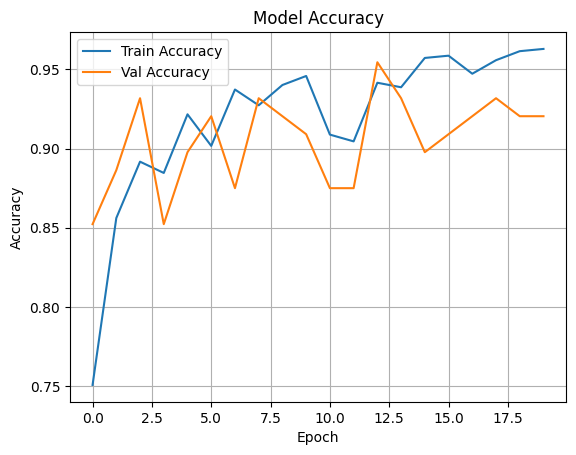

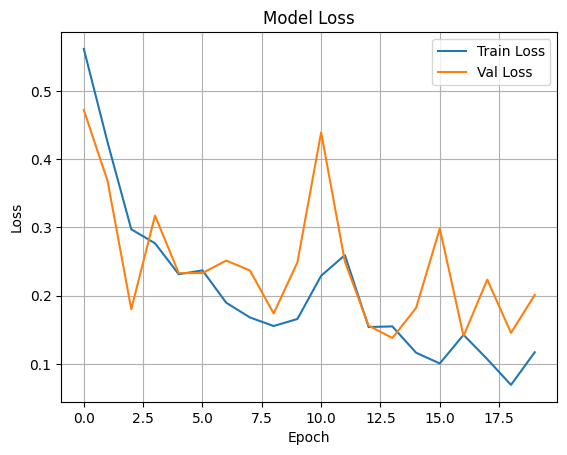

In [13]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step


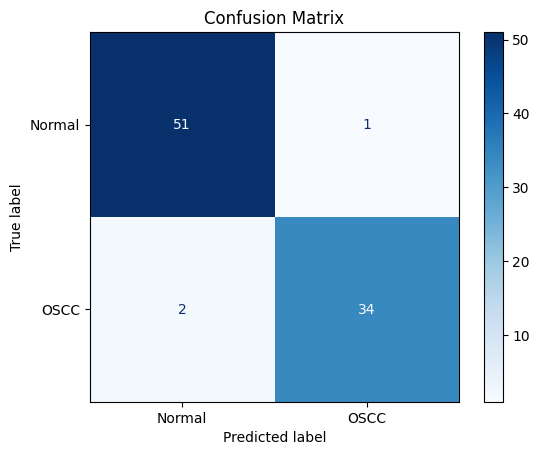

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict
y_pred_probs = model.predict(X_test)
y_pred = tf.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'OSCC'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [15]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'OSCC']))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97        52
        OSCC       0.97      0.94      0.96        36

    accuracy                           0.97        88
   macro avg       0.97      0.96      0.96        88
weighted avg       0.97      0.97      0.97        88



<ipython-input-16-4c357673e5b5>:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='gray')


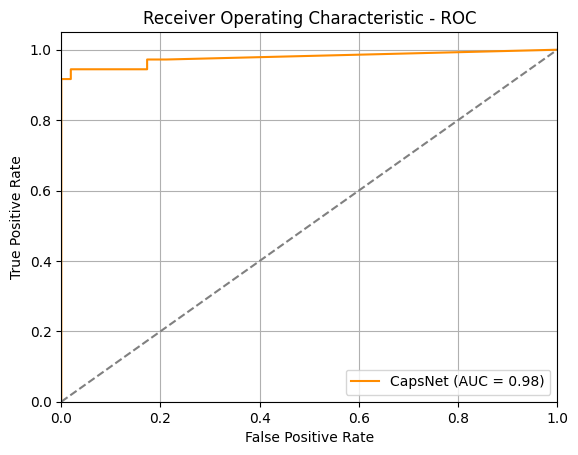

In [16]:
from sklearn.metrics import roc_curve, auc

# Get probabilities for class 1 (OSCC)
y_probs = y_pred_probs[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label='CapsNet (AUC = {:.2f})'.format(roc_auc), color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.utils import register_keras_serializable

# ✅ Register Squash Function
@register_keras_serializable()
def squash(vectors, axis=-1):
    s_squared_norm = K.sum(K.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / K.sqrt(s_squared_norm + K.epsilon())

# ✅ Register Custom Length Layer
@register_keras_serializable()
class Length(layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + K.epsilon())


In [23]:
model = tf.keras.models.load_model("capsnet_oscc_model1.h5", compile=False,
                                   custom_objects={"squash": squash, "Length": Length})


In [29]:
# Load the model (with custom objects like squash, Length if needed)
model = tf.keras.models.load_model("capsnet_oscc_model1.h5", compile=False,
                                   custom_objects={"squash": squash, "Length": Length})

# Function to recursively print all layers
def print_all_layers(model, prefix=''):
    for layer in model.layers:
        print(f"{prefix}{layer.name} - {layer.__class__.__name__}")
        # If the layer is a Model (e.g., MobileNetV2), go deeper
        if isinstance(layer, tf.keras.Model):
            print_all_layers(layer, prefix=prefix + '    ')

# Call the function
print("🔍 Listing all layers in your model:")
print_all_layers(model)


🔍 Listing all layers in your model:
input_layer_2 - InputLayer
mobilenetv2_1.00_160 - Functional
    input_layer_3 - InputLayer
    Conv1 - Conv2D
    bn_Conv1 - BatchNormalization
    Conv1_relu - ReLU
    expanded_conv_depthwise - DepthwiseConv2D
    expanded_conv_depthwise_BN - BatchNormalization
    expanded_conv_depthwise_relu - ReLU
    expanded_conv_project - Conv2D
    expanded_conv_project_BN - BatchNormalization
    block_1_expand - Conv2D
    block_1_expand_BN - BatchNormalization
    block_1_expand_relu - ReLU
    block_1_pad - ZeroPadding2D
    block_1_depthwise - DepthwiseConv2D
    block_1_depthwise_BN - BatchNormalization
    block_1_depthwise_relu - ReLU
    block_1_project - Conv2D
    block_1_project_BN - BatchNormalization
    block_2_expand - Conv2D
    block_2_expand_BN - BatchNormalization
    block_2_expand_relu - ReLU
    block_2_depthwise - DepthwiseConv2D
    block_2_depthwise_BN - BatchNormalization
    block_2_depthwise_relu - ReLU
    block_2_project - Con

In [34]:
# Load the image (your test image path)
img_path = "/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg"# ← Replace this
img = image.load_img(img_path, target_size=(160, 160))  # Your model input size
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize


In [37]:
img_array.shape  # should be (1, 160, 160, 3)


(1, 160, 160, 3)

In [39]:
print(model.output.shape)


(None, 2)


In [42]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)


0 input_layer_2 (None, 160, 160, 3)
1 mobilenetv2_1.00_160 (None, 5, 5, 1280)
2 conv2d_2 (None, 5, 5, 256)
3 conv2d_3 (None, 3, 3, 256)
4 reshape_2 (None, 288, 8)
5 lambda_1 (None, 288, 8)
6 global_average_pooling1d (None, 8)
7 dense_1 (None, 32)
8 reshape_3 (None, 2, 16)
9 capsnet_output (None, 2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


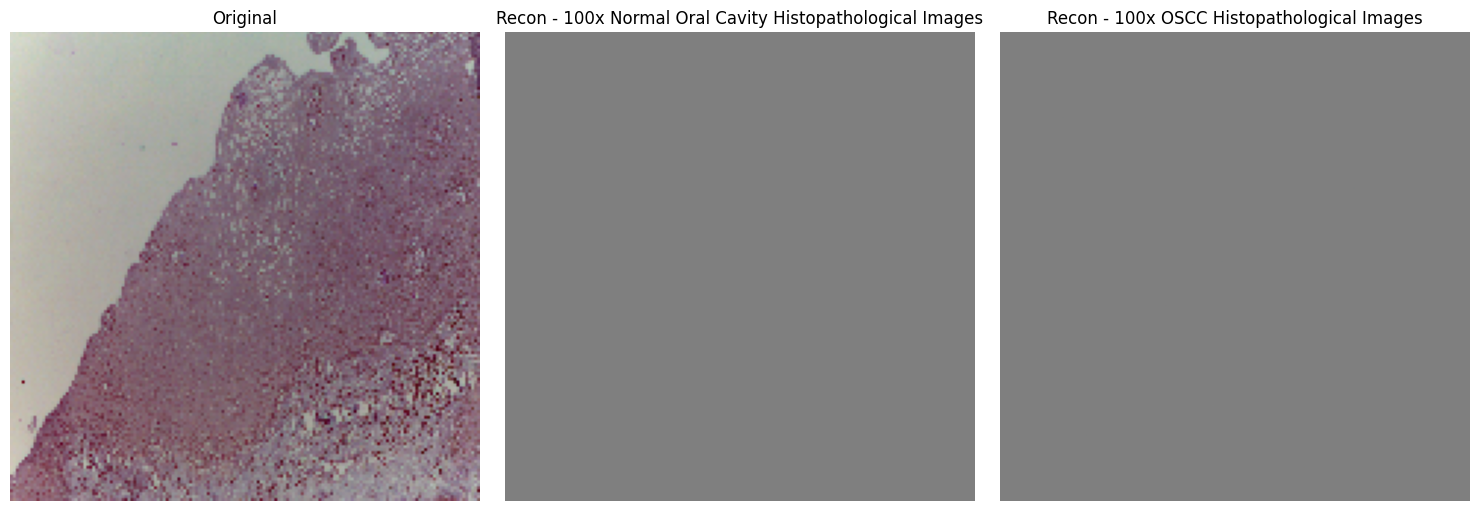

In [54]:
visualize_reconstruction_capsnet(model, sample, class_names=["100x Normal Oral Cavity Histopathological Images", "100x OSCC Histopathological Images"])


In [55]:
model = tf.keras.models.load_model(
    "capsnet_oscc_model1.h5",
    compile=False,
    custom_objects={"squash": squash, "Length": Length}
)


In [56]:
def build_decoder():
    decoder_input = tf.keras.Input(shape=(2, 16))  # (num_classes, capsule_dim)
    x = tf.keras.layers.Flatten()(decoder_input)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    x = tf.keras.layers.Dense(160 * 160 * 3, activation='sigmoid')(x)
    output = tf.keras.layers.Reshape((160, 160, 3))(x)
    return tf.keras.Model(inputs=decoder_input, outputs=output)


In [57]:
capsule_output_model = tf.keras.Model(inputs=model.input,
                                      outputs=model.get_layer("reshape_3").output)


In [58]:
def visualize_capsule_reconstruction(sample, capsule_output_model, decoder, class_names):
    # Get capsule outputs (shape: [1, 2, 16])
    caps_output = capsule_output_model.predict(sample)

    fig, axes = plt.subplots(1, len(class_names) + 1, figsize=(15, 5))
    axes[0].imshow(sample[0])
    axes[0].set_title("Original")
    axes[0].axis("off")

    # For each class, mask the capsule and decode
    for i in range(len(class_names)):
        masked = np.zeros_like(caps_output)
        masked[:, i, :] = caps_output[:, i, :]
        recon = decoder.predict(masked)
        recon = np.clip(recon[0], 0, 1)

        axes[i+1].imshow(recon)
        axes[i+1].set_title(f"Capsule {i}: {class_names[i]}")
        axes[i+1].axis("off")

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


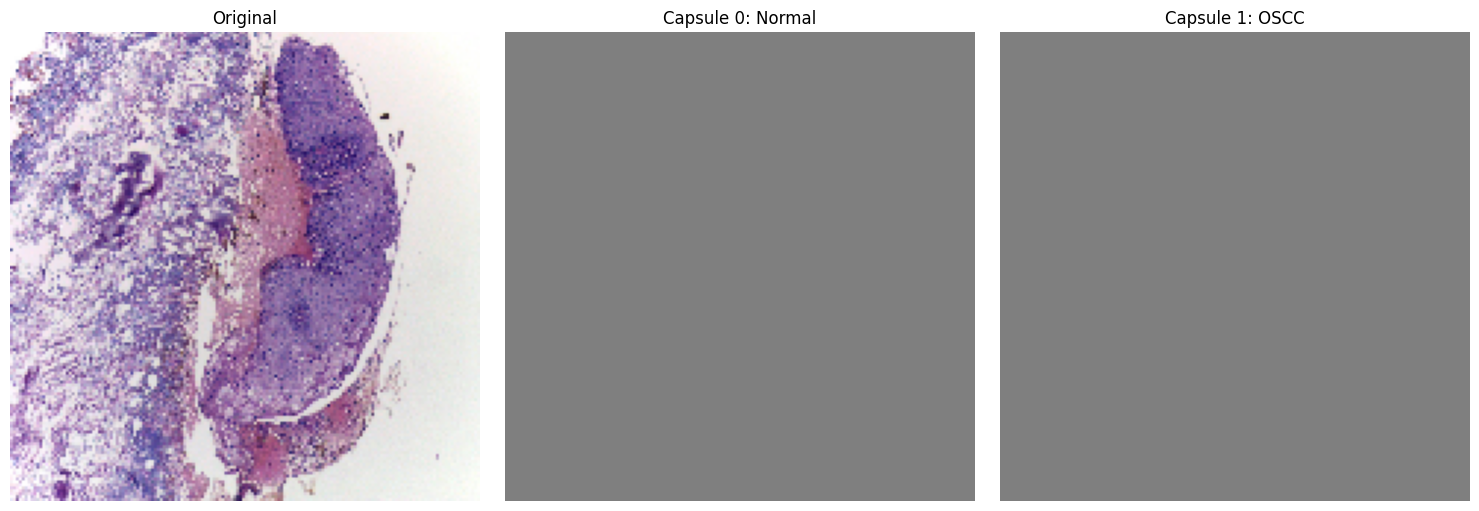

In [59]:
decoder = build_decoder()

# Prepare a sample image (160x160, normalized)
img_path = "/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg"
sample = tf.keras.preprocessing.image.load_img(img_path, target_size=(160, 160))
sample = tf.keras.preprocessing.image.img_to_array(sample)
sample = np.expand_dims(sample / 255.0, axis=0)

class_names = ["Normal", "OSCC"]
visualize_capsule_reconstruction(sample, capsule_output_model, decoder, class_names)


In [60]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Custom objects
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())
    return scale * vectors

class Length(tf.keras.layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), -1) + tf.keras.backend.epsilon())

# Load model
model = load_model("capsnet_oscc_model1.h5", compile=False,
                   custom_objects={"squash": squash, "Length": Length})


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


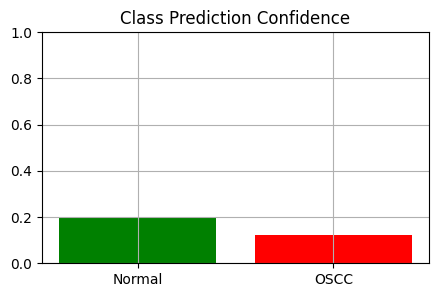

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load & preprocess test image
img_path = '/content/drive/MyDrive/Oral_cancer/First Set/100x OSCC Histopathological Images/OSCC_100x_9.jpg'
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_names = ["Normal", "OSCC"]

# Plot bar chart
plt.figure(figsize=(5, 3))
plt.bar(class_names, pred[0], color=['green', 'red'])
plt.title("Class Prediction Confidence")
plt.ylim([0, 1])
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


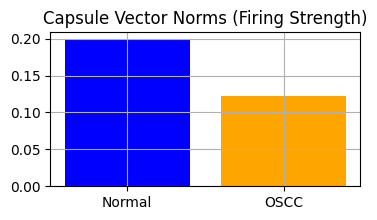

In [62]:
# Get capsule output from penultimate layer
capsule_layer = model.get_layer(index=-2)  # Usually the capsule layer
capsule_output_model = tf.keras.Model(inputs=model.input, outputs=capsule_layer.output)

caps_output = capsule_output_model.predict(img_array)  # shape (1, 2, 16)

# Compute norms (Length)
caps_norm = np.linalg.norm(caps_output[0], axis=-1)  # shape (2,)

plt.figure(figsize=(4, 2))
plt.bar(class_names, caps_norm, color=['blue', 'orange'])
plt.title("Capsule Vector Norms (Firing Strength)")
plt.grid(True)
plt.show()


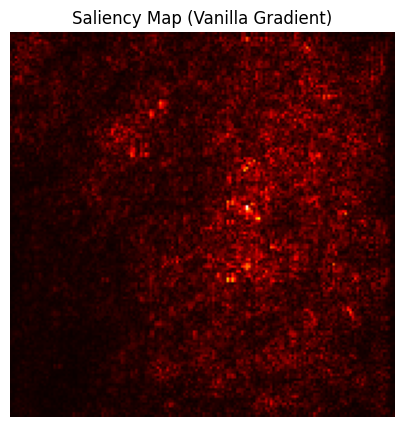

In [63]:
import tensorflow.keras.backend as K

# Get gradient of the correct class w.r.t. input image
img_tensor = tf.convert_to_tensor(img_array)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    preds = model(img_tensor)
    class_idx = tf.argmax(preds[0])
    class_output = preds[:, class_idx]

# Compute gradients
grads = tape.gradient(class_output, img_tensor)[0]

# Take absolute max gradient over color channels
saliency = np.max(np.abs(grads), axis=-1)

# Normalize
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map (Vanilla Gradient)")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


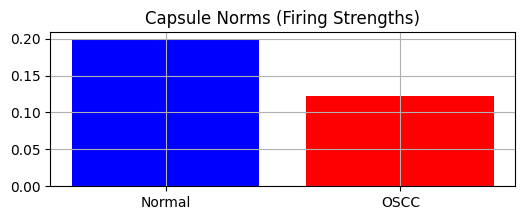

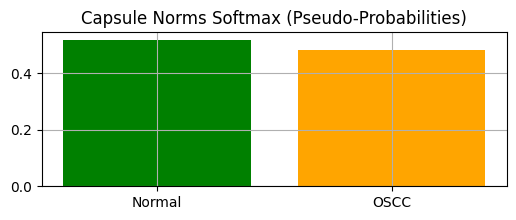

🧠 Predicted Class: Normal


In [65]:
# Predict capsule output (before Length layer)
capsule_layer_output = model.get_layer(index=-2).output  # e.g., shape (None, 2, 16)
caps_output_model = tf.keras.Model(inputs=model.input, outputs=capsule_layer_output)

caps_output = caps_output_model.predict(img_array)  # shape (1, 2, 16)
caps_norm = np.linalg.norm(caps_output[0], axis=-1)  # shape (2,)

# Normalize the norms as probabilities (softmax-style)
probs = tf.nn.softmax(caps_norm).numpy()

# Show capsule firing strengths
import matplotlib.pyplot as plt

class_names = ["Normal", "OSCC"]

plt.figure(figsize=(6, 2))
plt.bar(class_names, caps_norm, color=['blue', 'red'])
plt.title("Capsule Norms (Firing Strengths)")
plt.grid(True)
plt.show()

# Show softmax-normalized probabilities
plt.figure(figsize=(6, 2))
plt.bar(class_names, probs, color=['green', 'orange'])
plt.title("Capsule Norms Softmax (Pseudo-Probabilities)")
plt.grid(True)
plt.show()

# Print predicted class
print("🧠 Predicted Class:", class_names[np.argmax(probs)])


In [66]:
print("Caps Norms:", caps_norm)
print("Softmaxed:", probs)


Caps Norms: [0.19860289 0.12235978]
Softmaxed: [0.51905155 0.48094845]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


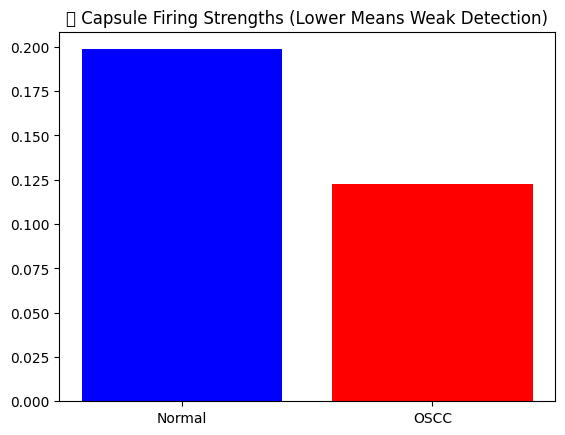

In [67]:
plt.bar(["Normal", "OSCC"], caps_norm, color=['blue', 'red'])
plt.title("🧠 Capsule Firing Strengths (Lower Means Weak Detection)")
plt.show()


In [78]:
def CapsNetModel(input_shape=(160, 160, 3), n_class=2, routings=3):
    inputs = tf.keras.Input(shape=input_shape)

    # ✅ Feature Extractor
    base_model = MobileNetV2(include_top=False, input_shape=input_shape, weights='imagenet')
    base_model.trainable = False
    x = base_model(inputs, training=False)
    conv_features = x  # For Grad-CAM

    # ✅ Extra Conv layer (named for Grad-CAM)
    x = layers.Conv2D(256, kernel_size=1, activation='relu', name="conv_xai_1")(x)
    x = layers.Conv2D(32 * 8, kernel_size=3, padding='valid', activation='relu', name="conv_xai_2")(x)

    # Capsule conversion
    x = layers.Reshape([-1, 8], name="capsule_reshape")(x)
    x = layers.Lambda(squash, name="squash_caps")(x)

    # ✅ Pooling to fixed size capsule output
    x = layers.GlobalAveragePooling1D(name="caps_pool")(x)
    x = layers.Dense(n_class * 16, activation='relu', name="caps_dense")(x)
    digit_caps = layers.Reshape((n_class, 16), name="digit_caps")(x)

    # ✅ Length layer
    out_caps = Length(name='capsnet_output')(digit_caps)

    # Full model
    model = models.Model(inputs=inputs, outputs=out_caps, name="CapsNet_XAI")
    return model


In [79]:
# Get convolutional layer for Grad-CAM
last_conv_layer = "conv_xai_2"

# Model for Grad-CAM
gradcam_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer).output, model.output]
)

# Model for capsule outputs
capsule_output_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer("digit_caps").output]
)


ValueError: No such layer: conv_xai_2. Existing layers are: ['input_layer_2', 'mobilenetv2_1.00_160', 'conv2d_2', 'conv2d_3', 'reshape_2', 'lambda_1', 'global_average_pooling1d', 'dense_1', 'reshape_3', 'capsnet_output'].

In [80]:
from tensorflow.keras import layers, models
import tensorflow as tf

def squash(x, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(x), axis=axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + 1e-9)
    return scale * x

def CapsNet_XAI_Model(input_shape=(160, 160, 3), n_class=2):
    inputs = tf.keras.Input(shape=input_shape, name="input_layer")

    # Base model
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        input_shape=input_shape,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)  # Feature maps
    x = layers.Conv2D(256, kernel_size=1, activation='relu', name="conv_xai_1")(x)
    x = layers.Conv2D(32 * 8, kernel_size=3, padding='valid', activation='relu', name="conv_xai_2")(x)

    # Reshape to capsules
    x = layers.Reshape([-1, 8], name="capsule_reshape")(x)
    x = layers.Lambda(squash, name="squash_caps")(x)
    x = layers.GlobalAveragePooling1D(name="caps_pool")(x)

    # Capsule output
    x = layers.Dense(n_class * 16, activation='relu', name="caps_dense")(x)
    digit_caps = layers.Reshape((n_class, 16), name="digit_caps")(x)

    # Output length layer
    out_caps = Length(name='capsnet_output')(digit_caps)

    return models.Model(inputs=inputs, outputs=out_caps, name="CapsNet_XAI")


In [81]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Capsule squash function
def squash(x, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(x), axis=axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + 1e-9)
    return scale * x

# Length layer for capsule output
class Length(layers.Layer):
    def call(self, inputs, **kwargs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), -1) + 1e-9)

# Full XAI-ready CapsNet model
def CapsNet_XAI_Model(input_shape=(160, 160, 3), n_class=2):
    inputs = tf.keras.Input(shape=input_shape, name="input_layer")

    # Base model
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        input_shape=input_shape,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)  # (None, 5, 5, 1280)

    # Extra conv layers for interpretability
    x = layers.Conv2D(256, kernel_size=1, activation='relu', name="conv_xai_1")(x)
    x = layers.Conv2D(32 * 8, kernel_size=3, padding='valid', activation='relu', name="conv_xai_2")(x)

    # Reshape into capsules
    x = layers.Reshape([-1, 8], name="capsule_reshape")(x)
    x = layers.Lambda(squash, name="squash_caps")(x)
    x = layers.GlobalAveragePooling1D(name="caps_pool")(x)

    # Final capsule representation
    x = layers.Dense(n_class * 16, activation='relu', name="caps_dense")(x)
    digit_caps = layers.Reshape((n_class, 16), name="digit_caps")(x)

    # Output layer: capsule length = class probabilities
    out_caps = Length(name='capsnet_output')(digit_caps)

    return models.Model(inputs=inputs, outputs=out_caps, name="CapsNet_XAI")


In [82]:
model = CapsNet_XAI_Model(input_shape=(160, 160, 3), n_class=2)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "CapsNet_XAI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_xai_1 (Conv2D)                  │ (None, 5, 5, 256)           │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_xai_2 (Conv2D)                  │ (None, 3, 3, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capsule_reshape (Reshape)            │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ squash_caps (Lambda)                 │ (None, 288, 8)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ caps_pool (GlobalAveragePooling1D)   │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ caps_dense (Dense)                   │ (None, 32)                  │             288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ digit_caps (Reshape)                 │ (None, 2, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ capsnet_output (Length)              │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,176,288 (12.12 MB)

 Trainable params: 918,304 (3.50 MB)

 Non-trainable params: 2,257,984 (8.61 MB)